# **Data Preprocessing**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

In [ ]:
df = pd.read_csv('Employee.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [ ]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [ ]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


## **1. Data Exploration**

In [ ]:
# 1. Data Exploration
for col in df.columns:
    uniques = df[col].unique()
    print(f"\nColumn: {col}")
    print(f"dtype: {df[col].dtype}")
    print(f"Number of unique values:: {df[col].nunique(dropna=False)}")
    print(f"Unique values: {uniques}")


Column: Company
dtype: object
Number of unique values:: 7
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']

Column: Age
dtype: float64
Number of unique values:: 30
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]

Column: Salary
dtype: float64
Number of unique values:: 41
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]

Column: Place
dtype: object
Number of unique values:: 12
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']

Column: Country
dtype: object
Number of unique values:: 1
Unique values: ['India']

Column: Gender
dtype: int64
Number of unique va

In [ ]:
# Renaming columns
print('Renaming columns to lowercase and removing spaces')
old_columns = df.columns.tolist()
new_columns = [c.strip().lower().replace(' ', '_') for c in old_columns]
df.columns = new_columns
print("old columns:",old_columns)
print('Columns after renaming:', df.columns.tolist())

Renaming columns to lowercase and removing spaces
old columns: ['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender']
Columns after renaming: ['company', 'age', 'salary', 'place', 'country', 'gender']


In [ ]:
df.describe()

,age,salary,gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


## **2. Data Cleaning**

In [ ]:
# 2. Data Cleaning
# Replace 0 in age as NaN
if 'age' in df.columns:
    n_zero_age = (df['age'] == 0).sum()
    print(f"Found {n_zero_age} Replace 0 in age as NaN ")
    df.loc[df['age'] == 0, 'age'] = np.nan

Found 6 Replace 0 in age as NaN 


In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
company     8
age        24
salary     24
place      14
country     0
gender      0
dtype: int64


In [ ]:
# Remove all duplicate rows
dups = df.duplicated().sum()
print(f"Duplicate rows found: {dups}")
if dups > 0:
    df = df.drop_duplicates()
print("Dropped duplicates. New shape:", df.shape)

Duplicate rows found: 4
Dropped duplicates. New shape: (144, 6)


In [ ]:
# Inappropriate values
if 'salary' in df.columns:
    bad_salary = df[df['salary'] < 0]
    print(f"Rows with salary < 0: {len(bad_salary)}")

Rows with salary < 0: 0


In [ ]:
# Outlier detection (IQR method for numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns detected for outlier detection:', numeric_cols)
outlier_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_info[col] = {'lower': lower, 'upper': upper, 'count': outliers.shape[0]}
print('\nOutlier summary (IQR method):')
for k,v in outlier_info.items():
    print(f" - {k}: lower={v['lower']}, upper={v['upper']}, outlier_count={v['count']}")

Numeric columns detected for outlier detection: ['age', 'salary', 'gender']

Outlier summary (IQR method):
 - age: lower=-2.5, upper=65.5, outlier_count=0
 - salary: lower=-4425.0, upper=15455.0, outlier_count=0
 - gender: lower=0.0, upper=0.0, outlier_count=32


In [ ]:
print(df.isnull().sum())

company     8
age        23
salary     23
place      14
country     0
gender      0
dtype: int64


In [ ]:
# treat missing values
# fill numeric-median, categorical-mode and numeric imputer-median
clean_fill = df.copy()
num_cols = clean_fill.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = clean_fill.select_dtypes(include=['object', 'category']).columns.tolist()

if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    clean_fill[num_cols] = num_imputer.fit_transform(clean_fill[num_cols])
if len(cat_cols) > 0:
    for c in cat_cols:
        mode_val = clean_fill[c].mode(dropna=True)
        if not mode_val.empty:
            clean_fill[c] = clean_fill[c].fillna(mode_val.iloc[0])
        else:
            clean_fill[c] = clean_fill[c].fillna('Unknown')
print('Shape after median/mode imputation:', clean_fill.shape)
print('Missing values now:\n', clean_fill.isna().sum())
df_clean = clean_fill.copy()
df=df_clean

Shape after median/mode imputation: (144, 6)
Missing values now:
 company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


## **3. Data Analysis**

Filtered rows (age>40 & salary<5000): 15


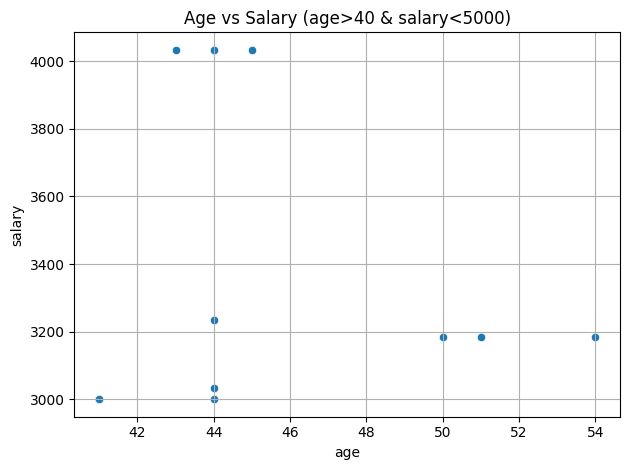

In [ ]:
# 3. Data Analysis
# Filter the data with age >40 and salary<5000
if 'age' in df_clean.columns and 'salary' in df_clean.columns:
    filt = df_clean[(df_clean['age'] > 40) & (df_clean['salary'] < 5000)]
    print('Filtered rows (age>40 & salary<5000):', filt.shape[0])
    sns.scatterplot(data=filt, x='age', y='salary')
    plt.title('Age vs Salary (age>40 & salary<5000)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print('Age or Salary not found in columns')

People count by place: place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


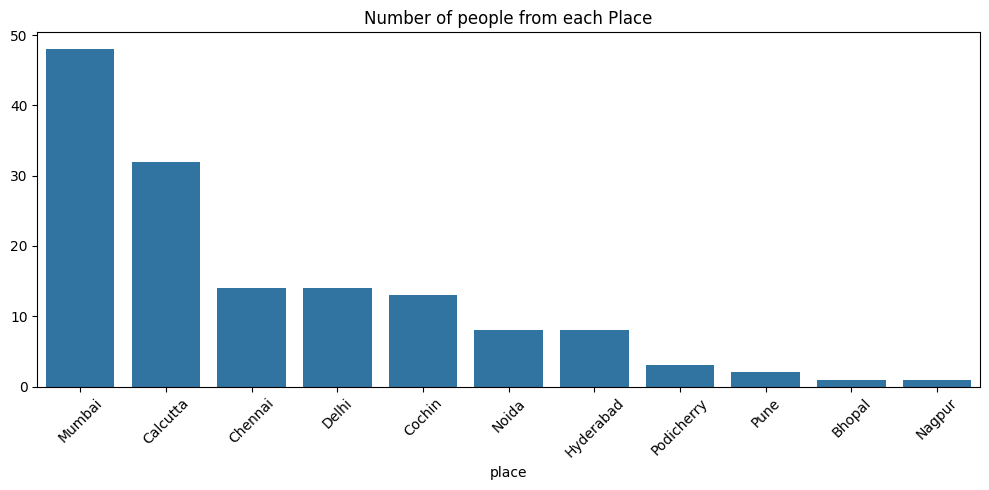

In [ ]:
# Count people from each place
if 'place' in df_clean.columns:
    place_counts = df_clean['place'].value_counts()
    print('People count by place:', place_counts)
    plt.figure(figsize=(10,5))
    sns.barplot(x=place_counts.index, y=place_counts.values)
    plt.title('Number of people from each Place')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## **4. Data Encoding**

In [ ]:
# 4. Data Encoding
# Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
df["country"]=pd.get_dummies(df["country"],dtype=int)
le=LabelEncoder()
df["company"]=le.fit_transform(df["company"])
df["place"]=le.fit_transform(df["place"])

Categorical columns: ['company', 'place', 'country']


In [ ]:
df

,company,age,salary,place,country,gender
0,4,20.0,5000.0,2,1,0.0
1,2,30.0,5000.0,6,1,0.0
2,4,35.0,2300.0,1,1,0.0
3,2,40.0,3000.0,4,1,0.0
4,4,23.0,4000.0,6,1,0.0
...,...,...,...,...,...,...
142,3,22.0,8202.0,6,1,0.0
143,4,33.0,9024.0,1,1,1.0
145,2,44.0,4034.0,4,1,1.0
146,4,33.0,5034.0,6,1,1.0


## **5. Feature Scaling**

In [ ]:
# 5. Feature Scaling
# After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler
X =df.copy()
X_before_scaling = X.copy()
std_scaler = StandardScaler()
X_std = X.copy()
num_features = X_std.select_dtypes(include=[np.number]).columns.tolist()
X_std[num_features] = std_scaler.fit_transform(X_std[num_features])
mm_scaler = MinMaxScaler()
X_mm = X.copy()
X_mm[num_features] = mm_scaler.fit_transform(X_mm[num_features])
print('Sample after StandardScaler (first 5 rows):')
print(X_std.head())
print('\nSample after MinMaxScaler (first 5 rows):')
print(X_mm.head())

Sample after StandardScaler (first 5 rows):
    company       age    salary     place  country    gender
0  0.991489 -1.484676 -0.100827 -0.893255      0.0 -0.534522
1 -0.239325 -0.267174 -0.100827  0.750562      0.0 -0.534522
2  0.991489  0.341577 -1.243735 -1.304209      0.0 -0.534522
3 -0.239325  0.950328 -0.947426 -0.071346      0.0 -0.534522
4  0.991489 -1.119426 -0.524127  0.750562      0.0 -0.534522

Sample after MinMaxScaler (first 5 rows):
   company       age    salary  place  country  gender
0      0.8  0.081081  0.445089    0.2      0.0     0.0
1      0.4  0.351351  0.445089    0.6      0.0     0.0
2      0.8  0.486486  0.137817    0.1      0.0     0.0
3      0.4  0.621622  0.217480    0.4      0.0     0.0
4      0.8  0.162162  0.331285    0.6      0.0     0.0
